# Pecora 1998 digitized-curve fitting

Load one digitized SANS series from Borsali, Nguyen, and Pecora
(*Macromolecules* **31**, 1548–1555, 1998), construct digitization-aware
uncertainties, and fit the same heterogeneous random-line model used in
`cf.ipynb`.

Set `SERIES_KEY` below and run the notebook from top to bottom. Work through
the datasets one at a time in this order:

`salt_free` → `10mM` → `50mM` → `0.5M` → `1M`

Each run writes only that series to `output/pecora`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import cf_tools as cf

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 200,
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


## Select one Pecora series

In [2]:
DATA_DIR = Path("data/pecora")
OUTPUT_DIR = Path("output/pecora")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Change only this selector, then Run All.
SERIES_KEY = "50mM"  # one of "salt_free", "10mM", "50mM", "0.5M", "1M"

SERIES_CONFIG = {
    "salt_free": {
        "file": "pecora_1998_salt_free.csv",
        "tag": "pecora_salt_free",
        "label": "salt-free",
        "characteristic_q": 0.061,
    },
    "10mM": {
        "file": "pecora_1998_10mM.csv",
        "tag": "pecora_10mM",
        "label": "10 mM",
        "characteristic_q": 0.061,
    },
    "50mM": {
        "file": "pecora_1998_50mM.csv",
        "tag": "pecora_50mM",
        "label": "50 mM",
        "characteristic_q": 0.055,
    },
    "0.5M": {
        "file": "pecora_1998_0.5M.csv",
        "tag": "pecora_0p5M",
        "label": "0.5 M",
        "characteristic_q": 0.050,
    },
    "1M": {
        "file": "pecora_1998_1M.csv",
        "tag": "pecora_1M",
        "label": "1 M",
        "characteristic_q": 0.050,
    },
}
if SERIES_KEY not in SERIES_CONFIG:
    raise KeyError(f"SERIES_KEY must be one of {tuple(SERIES_CONFIG)}")

config = SERIES_CONFIG[SERIES_KEY]
DATA_CSV = DATA_DIR / config["file"]
SAMPLE_TAG = config["tag"]
SERIES_LABEL = config["label"]
CHARACTERISTIC_Q = config["characteristic_q"]

# The figure calibration gives about ?0.003 in I(q); combine it with a
# modest relative term so densely overlapping high-q points are not overweighted.
DIGITIZATION_ERROR_ABSOLUTE = 0.003
DIGITIZATION_ERROR_RELATIVE = 0.03

FIT_Q_MIN = None
FIT_Q_MAX = None
LOWQ_ANCHOR_MAX = 0.025
HIGHQ_ANCHOR_MIN = 0.1

# Low-Q DAB anchor controls. Move the low-Q term directly by editing
# LOWQ_DAB_KAPPA_POSITION. Use (1.0, 1.0) to fix kappa exactly at that value;
# use a wider factor range to allow a local fit around the chosen position.
LOWQ_DAB_KAPPA_POSITION = 0.006
LOWQ_DAB_KAPPA_FACTOR_BOUNDS = (1.0, 1.0)
LOWQ_DAB_N_KAPPA = 96
LOWQ_INITIAL_KAPPA_SCALE = 1.0
LOWQ_ANCHOR_WEIGHT = 0.5

# Fit the raw high-q tail to I(q) = C/q + B, then fit the model to I(q) - B.
# B is allowed to be signed because the published curve has an arbitrary
# vertical offset; for salt-free data the fitted offset is negative.
SUBTRACT_BG = True

print(f"[status] series={SERIES_LABEL}")
print(f"[status] data={DATA_CSV}")
print(f"[status] output={OUTPUT_DIR}")
print(
    "[status] low-q DAB kappa control: "
    f"position={LOWQ_DAB_KAPPA_POSITION:.6g}, "
    f"factor_bounds={LOWQ_DAB_KAPPA_FACTOR_BOUNDS}"
)



[status] series=50 mM
[status] data=data\pecora\pecora_1998_50mM.csv
[status] output=output\pecora
[status] low-q DAB kappa control: position=0.006, factor_bounds=(1.0, 1.0)


## Load the digitized curve

In [3]:
table = np.genfromtxt(DATA_CSV, delimiter=",", names=True)
q = np.asarray(table["q_A1"], dtype=float)
intensity = np.asarray(table["I_q"], dtype=float)
good = np.isfinite(q) & np.isfinite(intensity) & (q > 0.0) & (intensity > 0.0)
q = q[good]
intensity = intensity[good]
order = np.argsort(q)
q = q[order]
intensity = intensity[order]

error = np.maximum(
    DIGITIZATION_ERROR_ABSOLUTE,
    DIGITIZATION_ERROR_RELATIVE * intensity,
)
profile = cf.RadialProfile(
    label=SAMPLE_TAG,
    q=q,
    intensity=intensity,
    error=error,
    count=np.ones(q.size, dtype=int),
)

fit_q_min = float(q.min()) if FIT_Q_MIN is None else float(FIT_Q_MIN)
fit_q_max = float(q.max()) if FIT_Q_MAX is None else float(FIT_Q_MAX)
LOWQ_ANCHOR_BOUNDS = (fit_q_min, min(LOWQ_ANCHOR_MAX, fit_q_max))
HIGHQ_ANCHOR_BOUNDS = (max(HIGHQ_ANCHOR_MIN, fit_q_min), 0.16)
OBSERVATION_CSV = OUTPUT_DIR / f"{SAMPLE_TAG}_digitized_observation.csv"
np.savetxt(
    OBSERVATION_CSV,
    cf.profile_table(profile),
    delimiter=",",
    header="Q,I,err,count",
    comments="",
)

print(f"[status] loaded {q.size} points over q=[{q.min():.6g}, {q.max():.6g}]")
print(f"[status] saved {OBSERVATION_CSV}")


[status] loaded 76 points over q=[0.0081481, 0.215006]
[status] saved output\pecora\pecora_50mM_digitized_observation.csv


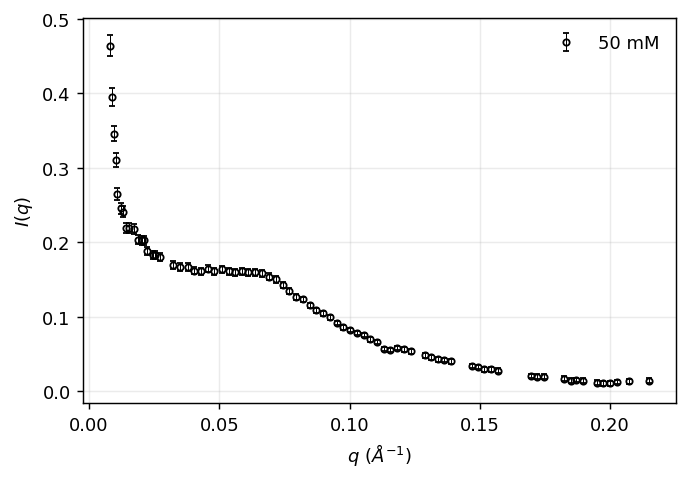

In [4]:
fig, ax = plt.subplots(figsize=(5.4, 3.8))
ax.errorbar(
    profile.q,
    profile.intensity,
    yerr=profile.error,
    fmt="o",
    ms=3.5,
    lw=0.55,
    capsize=1.5,
    color="k",
    markerfacecolor="none",
    label=SERIES_LABEL,
)
ax.set_xlabel(r"$q$ ($\AA^{-1}$)")
ax.set_ylabel(r"$I(q)$")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{SAMPLE_TAG}_digitized_observation.png")


## Low- and high-\(q\) anchor fits

The low-\(q\) DAB and high-\(q\) line anchors provide scale and correlation
length guidance. Higher-salt curves do not contain a clean local maximum, so
their model initialization uses the explicit `characteristic_q` in the series
configuration.


In [5]:
# First determine the constant offset on the raw digitized curve.
raw_highq_fit = cf.fit_highq_line_anchor(
    profile,
    HIGHQ_ANCHOR_BOUNDS,
    allow_signed_background=True,
)
working_profile = profile
background_subtracted = 0.0
if SUBTRACT_BG:
    background_subtracted = raw_highq_fit.parameters["background"]
    working_profile = cf.subtract_constant_background(profile, background_subtracted)

CORRECTED_OBSERVATION_CSV = OUTPUT_DIR / f"{SAMPLE_TAG}_background_corrected_observation.csv"
np.savetxt(
    CORRECTED_OBSERVATION_CSV,
    cf.profile_table(working_profile),
    delimiter=",",
    header="Q,I,err,count",
    comments="",
)


def fit_lowq_dab_anchor_near_kappa(
    profile,
    q_bounds,
    *,
    kappa_position,
    kappa_factor_bounds=(1.0, 1.0),
    n_kappa=1,
    background_max=None,
):
    """Notebook-local DAB anchor with direct control of the low-q position."""
    kappa_position = float(kappa_position)
    if not np.isfinite(kappa_position) or kappa_position <= 0.0:
        raise ValueError("LOWQ_DAB_KAPPA_POSITION must be positive and finite.")
    factor_min, factor_max = map(float, kappa_factor_bounds)
    if factor_min <= 0.0 or factor_max <= 0.0 or factor_min > factor_max:
        raise ValueError("LOWQ_DAB_KAPPA_FACTOR_BOUNDS must be positive and ordered.")

    mask = cf._fit_mask(profile, q_bounds)
    q_fit = profile.q[mask]
    y_fit_obs = profile.intensity[mask]
    err_fit = profile.error[mask]
    if q_fit.size < 4:
        raise ValueError("Need at least four positive points for the DAB anchor fit.")

    if np.isclose(factor_min, factor_max):
        kappa_grid = np.asarray([kappa_position * factor_min], dtype=float)
    else:
        kappa_grid = np.geomspace(
            kappa_position * factor_min,
            kappa_position * factor_max,
            int(n_kappa),
        )

    best = None
    for kappa in kappa_grid:
        basis = 1.0 / (q_fit * q_fit + kappa * kappa) ** 2
        amplitude, background, y_model = cf._fit_positive_basis_with_bounded_background(
            basis,
            y_fit_obs,
            err_fit,
            background_max=background_max,
        )
        if amplitude <= 0.0:
            continue
        score = cf._relative_rmse(y_fit_obs, y_model)
        if best is None or score < best[0]:
            best = (score, float(kappa), float(amplitude), float(background), y_model)
    if best is None:
        raise ValueError("Controlled DAB anchor fit did not find a positive-amplitude solution.")

    score, kappa, amplitude, background, y_model = best
    return cf.AnchorFit(
        name="lowQ_DAB",
        parameters={
            "amplitude": amplitude,
            "kappa": kappa,
            "background": background,
            "kappa_position": kappa_position,
        },
        q_fit_min=float(q_bounds[0]),
        q_fit_max=float(q_bounds[1]),
        q=q_fit,
        y=y_fit_obs,
        y_fit=y_model,
        relative_rmse=score,
    )


anchor_background_max = 0.0
lowq_dab_fit = fit_lowq_dab_anchor_near_kappa(
    working_profile,
    LOWQ_ANCHOR_BOUNDS,
    kappa_position=LOWQ_DAB_KAPPA_POSITION,
    kappa_factor_bounds=LOWQ_DAB_KAPPA_FACTOR_BOUNDS,
    n_kappa=LOWQ_DAB_N_KAPPA,
    background_max=anchor_background_max,
)
lowq_porod_fit = cf.fit_lowq_porod_anchor(
    working_profile,
    LOWQ_ANCHOR_BOUNDS,
    background_max=anchor_background_max,
)
highq_line_fit = cf.fit_highq_line_anchor(
    working_profile,
    HIGHQ_ANCHOR_BOUNDS,
    background_max=anchor_background_max,
)

print(
    "[background] raw high-q fit: "
    f"I(q)={raw_highq_fit.parameters['coefficient']:.6g}/q "
    f"+ ({raw_highq_fit.parameters['background']:.6g})"
)
print(f"[background] subtracted B={background_subtracted:.6g}")
print(f"[background] saved {CORRECTED_OBSERVATION_CSV}")
print(
    "[anchor] DAB controlled kappa="
    f"{lowq_dab_fit.parameters['kappa']:.6g} "
    f"(position={LOWQ_DAB_KAPPA_POSITION:.6g}, "
    f"factor_bounds={LOWQ_DAB_KAPPA_FACTOR_BOUNDS}), "
    f"rel_rmse={lowq_dab_fit.relative_rmse:.4g}"
)
print(f"[anchor] Q^-4 rel_rmse={lowq_porod_fit.relative_rmse:.4g}")
print(f"[anchor] high-q coefficient={highq_line_fit.parameters['coefficient']:.6g}, "
      f"rel_rmse={highq_line_fit.relative_rmse:.4g}")

anchor_rows = [
    ("subtracted_background", background_subtracted, np.nan, np.nan, np.nan),
    ("characteristic_q", CHARACTERISTIC_Q, np.nan, np.nan, np.nan),
    ("lowQ_DAB_kappa_position", LOWQ_DAB_KAPPA_POSITION,
     LOWQ_DAB_KAPPA_FACTOR_BOUNDS[0], LOWQ_DAB_KAPPA_FACTOR_BOUNDS[1], np.nan),
    ("lowQ_DAB", lowq_dab_fit.parameters["kappa"],
     lowq_dab_fit.parameters["amplitude"], lowq_dab_fit.parameters["background"],
     lowq_dab_fit.relative_rmse),
    ("lowQ_Qminus4", lowq_porod_fit.parameters["coefficient"], np.nan,
     lowq_porod_fit.parameters["background"], lowq_porod_fit.relative_rmse),
    ("highQ_line", highq_line_fit.parameters["coefficient"],
     highq_line_fit.parameters["rho0_apparent"],
     highq_line_fit.parameters["background"], highq_line_fit.relative_rmse),
]
with open(OUTPUT_DIR / f"{SAMPLE_TAG}_anchor_guesses.csv", "w", encoding="utf-8") as fh:
    fh.write("name,value_1,value_2,background,relative_rmse\n")
    for row in anchor_rows:
        fh.write(",".join(str(value) for value in row) + "\n")




[background] raw high-q fit: I(q)=0.014729/q + (-0.0665843)
[background] subtracted B=-0.0665843
[background] saved output\pecora\pecora_50mM_background_corrected_observation.csv
[anchor] DAB controlled kappa=0.006 (position=0.006, factor_bounds=(1.0, 1.0)), rel_rmse=0.6079
[anchor] Q^-4 rel_rmse=0.6909
[anchor] high-q coefficient=0.014729, rel_rmse=0.01691


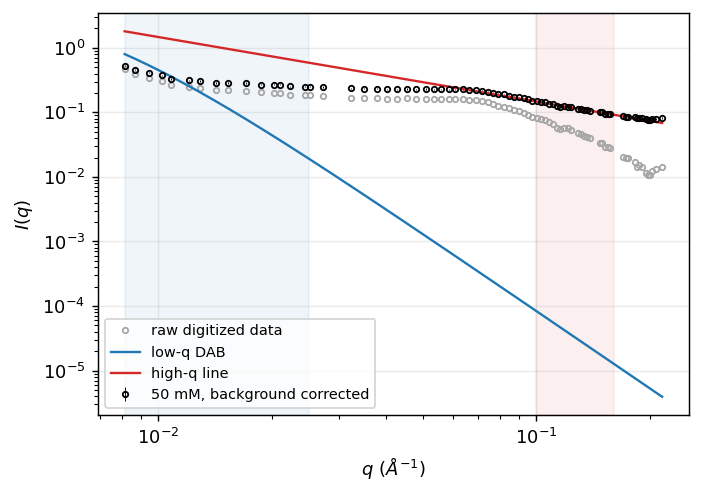

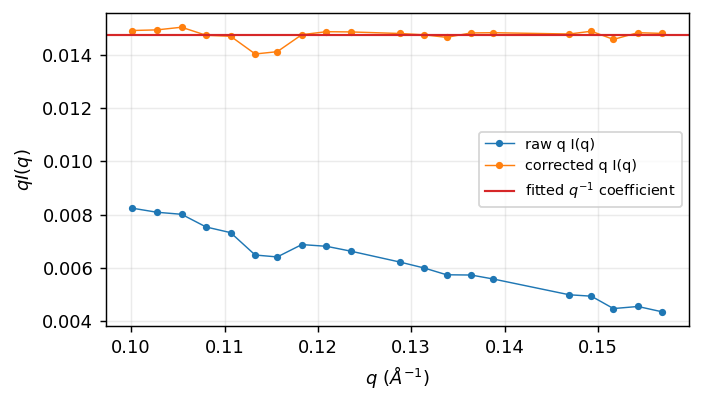

In [6]:
q_grid = np.geomspace(fit_q_min, fit_q_max, 400)
fig, ax = plt.subplots(figsize=(5.5, 3.9))
if SUBTRACT_BG:
    ax.plot(
        profile.q,
        profile.intensity,
        "o",
        ms=3,
        color="0.65",
        markerfacecolor="none",
        label="raw digitized data",
    )
ax.errorbar(
    working_profile.q,
    working_profile.intensity,
    yerr=working_profile.error,
    fmt="o",
    ms=3,
    lw=0.5,
    color="k",
    markerfacecolor="none",
    label=f"{SERIES_LABEL}, background corrected",
)
for label, anchor, color in (
    ("low-q DAB", lowq_dab_fit, "C0"),
    ("high-q line", highq_line_fit, "C3"),
):
    ax.plot(q_grid, cf.evaluate_anchor_fit(anchor, q_grid), lw=1.3, color=color, label=label)
ax.axvspan(*LOWQ_ANCHOR_BOUNDS, color="C0", alpha=0.07)
ax.axvspan(*HIGHQ_ANCHOR_BOUNDS, color="C3", alpha=0.07)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$q$ ($\AA^{-1}$)")
ax.set_ylabel(r"$I(q)$")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{SAMPLE_TAG}_anchor_fits.png")

# A q^-1 tail is horizontal when plotted as q I(q).
highq = (profile.q >= HIGHQ_ANCHOR_BOUNDS[0]) & (profile.q <= HIGHQ_ANCHOR_BOUNDS[1])
fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.plot(profile.q[highq], profile.q[highq] * profile.intensity[highq], "o-", ms=3, lw=0.8, label="raw q I(q)")
ax.plot(
    working_profile.q[highq],
    working_profile.q[highq] * working_profile.intensity[highq],
    "o-",
    ms=3,
    lw=0.8,
    label="corrected q I(q)",
)
ax.axhline(
    highq_line_fit.parameters["coefficient"],
    color="C3",
    lw=1.2,
    label=r"fitted $q^{-1}$ coefficient",
)
ax.set_xlabel(r"$q$ ($\AA^{-1}$)")
ax.set_ylabel(r"$q I(q)$")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{SAMPLE_TAG}_highq_background_check.png")


## Initial heterogeneous-line model

In [7]:
fit_distribution_parameter_set = {
    "r_sigma_k": {"initial": 0.28, "bounds": (0.10, 0.60)},
    "skewness": {"initial": 0.0, "bounds": (-1.5, 1.5)},
}

lowq_kappa_initial = LOWQ_INITIAL_KAPPA_SCALE * lowq_dab_fit.parameters["kappa"]
fit_initial = cf.initial_heterogeneous_guess_from_anchors(
    q_peak=0.04,
    lowq_kappa=lowq_kappa_initial,
    highq_coefficient=highq_line_fit.parameters["coefficient"],
    b0=-1.0,
    r_sigma_k0=0.28,
    distribution_parameter_set=fit_distribution_parameter_set,
)
fit_initial["k_H_over_k"] = 0.05
fit_initial["r_sigma_k"] = 0.33
fit_initial["b"] = -1.75
fit_initial["mean_k"] = 0.04
fit_bounds = {
    "mean_k": (0.03, 0.05),
    "k_H_over_k": (0.01, 0.20),
    "b": (-3.0, 0.0),
    "r_sigma_k": (0.10, 0.38),
}
fit_model_settings = {
    "k_distribution": "max_entropy_radial",
    "regression_loss": "relative",
    "num_modes_k": 2**8,
    "Nr": 1600,
    "Nr_small": 400,
    "N_samp_U": 2**12,
    "N_samp_st": 2**7,
    "NQ": 160,
    "progress": False,
}
print("[status] initial guess")
print(f"  lowq_kappa_initial  {lowq_kappa_initial:.8g}")
for key, value in fit_initial.items():
    print(f"  {key:20s} {value:.8g}")


[status] initial guess
  lowq_kappa_initial  0.006
  scale                30.438372
  mean_k               0.04
  r_sigma_k            0.33
  k_H_over_k           0.05
  b                    -1.75
  skewness             0


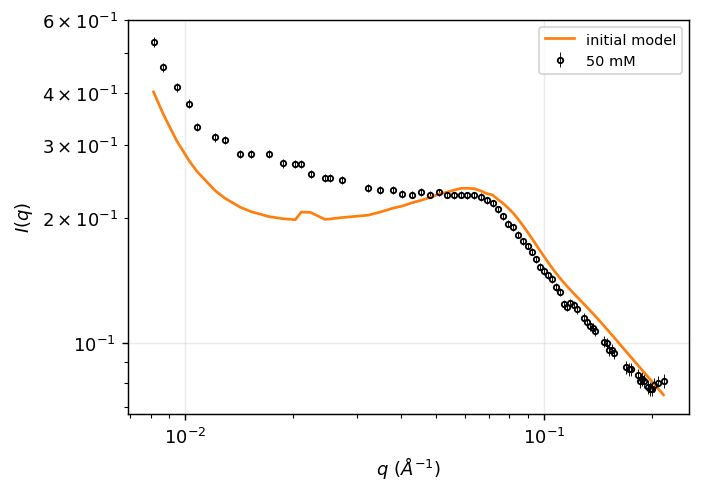

In [8]:
initial_model = cf.evaluate_heterogeneous_line_guess(
    working_profile,
    q_bounds=(fit_q_min, fit_q_max),
    parameters=fit_initial,
    model_settings=fit_model_settings,
    distribution_parameter_set=fit_distribution_parameter_set,
    log_error_floor=0.04,
)

fig, ax = plt.subplots(figsize=(5.5, 3.9))
ax.errorbar(
    working_profile.q,
    working_profile.intensity,
    yerr=working_profile.error,
    fmt="o",
    ms=3,
    lw=0.5,
    color="k",
    markerfacecolor="none",
    label=SERIES_LABEL,
)
ax.plot(initial_model.q, initial_model.model, color="C1", lw=1.5, label="initial model")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$q$ ($\AA^{-1}$)")
ax.set_ylabel(r"$I(q)$")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{SAMPLE_TAG}_initial_guess_fit.png")


## Constrained heterogeneous-line fit

In [9]:
hetero_fit = cf.fit_heterogeneous_line_least_squares(
    working_profile,
    q_bounds=(fit_q_min, fit_q_max),
    initial=fit_initial,
    lowq_kappa_anchor=lowq_dab_fit.parameters["kappa"],
    highq_coefficient_anchor=highq_line_fit.parameters["coefficient"],
    bounds=fit_bounds,
    model_settings=fit_model_settings,
    distribution_parameter_set=fit_distribution_parameter_set,
    max_nfev=100,
    anchor_weight=LOWQ_ANCHOR_WEIGHT,
    log_error_floor=0.04,
)
print(f"[status] fit success={hetero_fit.success}, nfev={hetero_fit.nfev}, "
      f"cost={hetero_fit.cost:.6g}")
print(f"[status] {hetero_fit.message}")
for key, value in hetero_fit.parameters.items():
    print(f"  {key:20s} {value:.8g}")

with open(OUTPUT_DIR / f"{SAMPLE_TAG}_fit_parameters.csv", "w", encoding="utf-8") as fh:
    fh.write("name,value\n")
    for key, value in hetero_fit.parameters.items():
        fh.write(f"{key},{value}\n")
np.savetxt(
    OUTPUT_DIR / f"{SAMPLE_TAG}_fit_curve.csv",
    np.column_stack([
        hetero_fit.q,
        hetero_fit.intensity,
        hetero_fit.error,
        hetero_fit.model,
        hetero_fit.model / hetero_fit.intensity,
    ]),
    delimiter=",",
    header="Q,I_obs,err,I_fit,I_fit_over_I_obs",
    comments="",
)




[status] fit success=True, nfev=26, cost=29.1022
[status] `xtol` termination condition is satisfied.
  scale                29.284529
  mean_k               0.036977751
  r_sigma_k            0.37999973
  k_H_over_k           0.19845419
  b                    -1.9711825
  k_H                  0.0073355347
  p_H                  0.9756485
  sigma_H_squared      0.023758508
  alpha_H              9.6594537e-05
  kappa_H              0.004065682
  rho0                 0.00016590189
  highq_coefficient    0.014891307
  skewness             -0.089168108


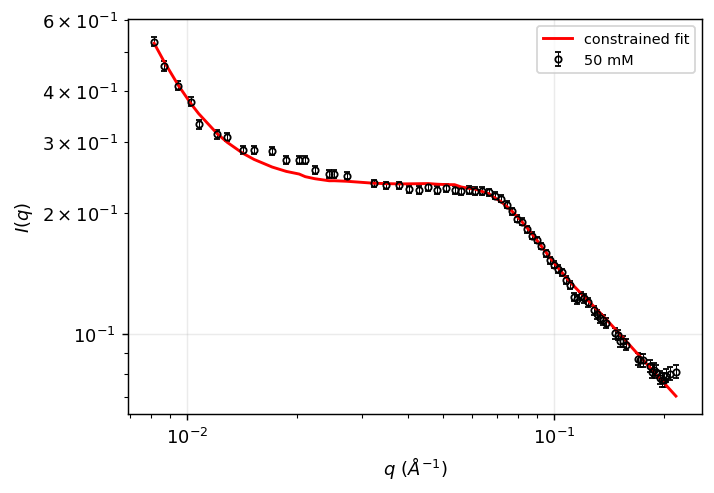

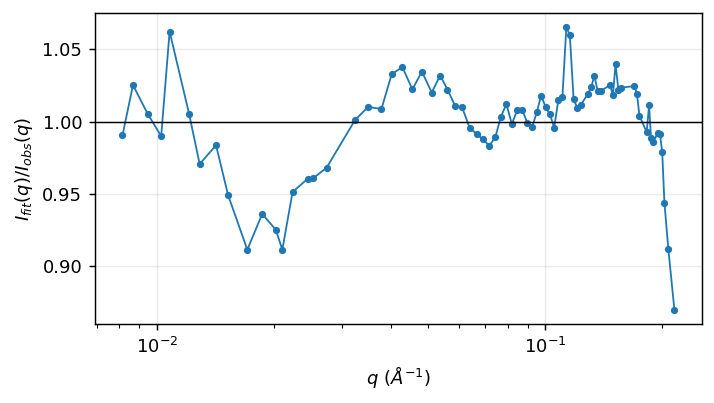

In [10]:
fig, ax = plt.subplots(figsize=(5.6, 3.9))
ax.errorbar(
    working_profile.q,
    working_profile.intensity,
    yerr=working_profile.error,
    fmt="o",
    ms=3.5,
    lw=0.55,
    capsize=1.5,
    color="k",
    markerfacecolor="none",
    label=SERIES_LABEL,
)
ax.plot(hetero_fit.q, hetero_fit.model, color="r", lw=1.6, label="constrained fit")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$q$ ($\AA^{-1}$)")
ax.set_ylabel(r"$I(q)$")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{SAMPLE_TAG}_constrained_fit.png")

fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.semilogx(
    hetero_fit.q,
    hetero_fit.model / hetero_fit.intensity,
    "o-",
    ms=3,
    lw=1.0,
)
ax.axhline(1.0, color="k", lw=0.8)
ax.set_xlabel(r"$q$ ($\AA^{-1}$)")
ax.set_ylabel(r"$I_{fit}(q)/I_{obs}(q)$")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{SAMPLE_TAG}_constrained_fit_ratio.png")


## Optional 3D preview

The numerical fit is complete above. Set `RUN_3D_PREVIEW = True` only when a
PyVista rendering is wanted for the currently selected series.


In [11]:
RUN_3D_PREVIEW = False

if RUN_3D_PREVIEW:
    try:
        import pyvista as pv
    except ImportError as exc:
        raise RuntimeError("PyVista is required for the optional 3D preview") from exc

    pv.set_jupyter_backend("html")
    preview_path = OUTPUT_DIR / f"{SAMPLE_TAG}_fit_heterogeneous_preview.png"
    fit_preview = cf.render_fit_heterogeneous_preview(
        hetero_fit.parameters,
        output_path=preview_path,
        visual_k_line=10.0,
        line_k_distribution=fit_model_settings["k_distribution"],
        line_r_sigma_k=hetero_fit.parameters["r_sigma_k"],
        line_k_distribution_params={
            name: hetero_fit.parameters[name]
            for name in fit_distribution_parameter_set
        },
        random_seed=114514,
        num_line_modes=128,
        nx=150,
        ny=150,
        nz=8,
        lateral_size_over_mask_length=15.0,
        thickness_over_mask_length=0.8,
        line_tube_radius_fraction=0.002,
        min_retained_line_length_over_k=10.0,
        show_mask_boundary=False,
        show_box_boundary=True,
        show_rejected_lines=False,
        window_size=(800, 800),
        window_fill_fraction=0.95,
        initial_view="normal",
        screenshot_scale=3,
    )
    print(f"[status] preview saved to {fit_preview.screenshot_path}")
    fit_preview.plotter.show(jupyter_backend="html")
